# Lesson 2 : LangGraph Components

In [7]:
from dotenv import load_dotenv
_ = load_dotenv()

In [ ]:
# !pip install langchain_community

  Using cached dataclasses_json-0.6.7-py3-none-any.whl.metadata (25 kB)
  Using cached typing_inspect-0.9.0-py3-none-any.whl.metadata (1.5 kB)
  Using cached mypy_extensions-1.1.0-py3-none-any.whl.metadata (1.1 kB)
   ---------------------------------------- 0.0/2.5 MB ? eta -:--:--
   ---------------------------------------- 2.5/2.5 MB 48.3 MB/s  0:00:00
Using cached dataclasses_json-0.6.7-py3-none-any.whl (28 kB)
   ---------------------------------------- 0.0/1.0 MB ? eta -:--:--
   ---------------------------------------- 1.0/1.0 MB 48.7 MB/s  0:00:00
Using cached typing_inspect-0.9.0-py3-none-any.whl (8.8 kB)
Using cached mypy_extensions-1.1.0-py3-none-any.whl (5.0 kB)

  Attempting uninstall: langchain-core

    Found existing installation: langchain-core 0.3.83

    Uninstalling langchain-core-0.3.83:

      Successfully uninstalled langchain-core-0.3.83

   -------------------- ------------------- 4/8 [langchain-core]
   -------------------- ------------------- 4/8 [langchain-c

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
langchain 0.3.27 requires langchain-core<1.0.0,>=0.3.72, but you have langchain-core 1.2.7 which is incompatible.
langchain 0.3.27 requires langchain-text-splitters<1.0.0,>=0.3.9, but you have langchain-text-splitters 1.1.0 which is incompatible.
langchain-openai 0.3.23 requires langchain-core<1.0.0,>=0.3.65, but you have langchain-core 1.2.7 which is incompatible.


In [4]:
from langgraph.graph import StateGraph, END
from typing import TypedDict, Annotated
import operator
from langchain_core.messages import AnyMessage, SystemMessage, HumanMessage, ToolMessage
from langchain_openai import ChatOpenAI
from langchain_community.tools.tavily_search import TavilySearchResults

In [8]:
tool = TavilySearchResults(max_results=4) #increased number of results
print(type(tool))
print(tool.name)

<class 'langchain_community.tools.tavily_search.tool.TavilySearchResults'>
tavily_search_results_json


> If you are not familiar with python typing annotation, you can refer to the [python documents](https://docs.python.org/3/library/typing.html).

In [9]:
class AgentState(TypedDict):
    messages: Annotated[list[AnyMessage], operator.add]

> Note: in `take_action` below, some logic was added to cover the case that the LLM returned a non-existent tool name. Even with function calling, LLMs can still occasionally hallucinate. Note that all that is done is instructing the LLM to try again! An advantage of an agentic organization.

In [10]:
class Agent:

    def __init__(self, model, tools, system=""):
        self.system = system
        graph = StateGraph(AgentState)
        graph.add_node("llm", self.call_openai)
        graph.add_node("action", self.take_action)
        graph.add_conditional_edges(
            "llm",
            self.exists_action,
            {True: "action", False: END}
        )
        graph.add_edge("action", "llm")
        graph.set_entry_point("llm")
        self.graph = graph.compile()
        self.tools = {t.name: t for t in tools}
        self.model = model.bind_tools(tools)

    def exists_action(self, state: AgentState):
        result = state['messages'][-1]
        return len(result.tool_calls) > 0

    def call_openai(self, state: AgentState):
        messages = state['messages']
        if self.system:
            messages = [SystemMessage(content=self.system)] + messages
        message = self.model.invoke(messages)
        return {'messages': [message]}

    def take_action(self, state: AgentState):
        tool_calls = state['messages'][-1].tool_calls
        results = []
        for t in tool_calls:
            print(f"Calling: {t}")
            if not t['name'] in self.tools:      # check for bad tool name from LLM
                print("\n ....bad tool name....")
                result = "bad tool name, retry"  # instruct LLM to retry if bad
            else:
                result = self.tools[t['name']].invoke(t['args'])
            results.append(ToolMessage(tool_call_id=t['id'], name=t['name'], content=str(result)))
        print("Back to the model!")
        return {'messages': results}

In [11]:
prompt = """You are a smart research assistant. Use the search engine to look up information. \
You are allowed to make multiple calls (either together or in sequence). \
Only look up information when you are sure of what you want. \
If you need to look up some information before asking a follow up question, you are allowed to do that!
"""

model = ChatOpenAI(model="gpt-3.5-turbo")  #reduce inference cost
abot = Agent(model, [tool], system=prompt)

In [ ]:
# !pip install pygraphviz

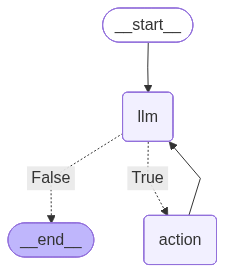

In [16]:
from IPython.display import Image, display

# Use draw_mermaid_png() instead of draw_png()
display(Image(abot.graph.get_graph().draw_mermaid_png()))

In [17]:
messages = [HumanMessage(content="What is the weather in sf?")]
result = abot.graph.invoke({"messages": messages})

Calling: {'name': 'tavily_search_results_json', 'args': {'query': 'weather in San Francisco'}, 'id': 'call_4b601jm09vpyIETxzo7qXPEd', 'type': 'tool_call'}
Back to the model!


In [18]:
result

{'messages': [HumanMessage(content='What is the weather in sf?', additional_kwargs={}, response_metadata={}),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'call_4b601jm09vpyIETxzo7qXPEd', 'function': {'arguments': '{"query":"weather in San Francisco"}', 'name': 'tavily_search_results_json'}, 'type': 'function'}], 'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 21, 'prompt_tokens': 153, 'total_tokens': 174, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-3.5-turbo-0125', 'system_fingerprint': None, 'id': 'chatcmpl-D0BMbuXeulrZPDjxAoIyL68PKKCq9', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run--019bdcce-1911-7f22-97ca-8fa8c477f892-0', tool_calls=[{'name': 'tavily_search_results_json', 'args': {'query': 'weather in San Francisco'}, '

In [19]:
result['messages'][-1].content

'The current weather in San Francisco, CA is as follows:\n\n- Temperature: 50°F\n- Feels Like: 45°F\n- Precipitation: 0%\n- Wind: 9 mph\n- Humidity: 78%\n\nFor more detailed information, you can visit [this link](https://weathershogun.com/weather/usa/ca/san-francisco/480/january/2026-01-20).'

In [20]:
messages = [HumanMessage(content="What is the weather in SF and LA?")]
result = abot.graph.invoke({"messages": messages})

Calling: {'name': 'tavily_search_results_json', 'args': {'query': 'weather in San Francisco'}, 'id': 'call_6t3W5qS5qk7tpIrq9Bmx1wiF', 'type': 'tool_call'}
Calling: {'name': 'tavily_search_results_json', 'args': {'query': 'weather in Los Angeles'}, 'id': 'call_dxbv47auwf7PbApVjp4I4G6x', 'type': 'tool_call'}
Back to the model!


In [21]:
result['messages'][-1].content

'The current weather in San Francisco is 50°F with a feels-like temperature of 45°F. The wind speed is 9 mph, and the humidity is 78%. The daytime temperature is expected to reach 57°F with a nighttime low of 48°F. There is no precipitation expected, and the UV Index is 3.\n\nIn Los Angeles, temperatures range from a low of 11°C to a high of 21°C in January. There could be about 3 to 8 days of rain in Los Angeles during the month. Los Angeles is expected to have temperatures in the 70s, which is 5 to 10 degrees above historical averages.\n\nIf you need more detailed information or specific details, feel free to ask!'

In [22]:
# Note, the query was modified to produce more consistent results. 
# Results may vary per run and over time as search information and models change.

query = "Who won the super bowl in 2024? In what state is the winning team headquarters located? \
What is the GDP of that state? Answer each question." 
messages = [HumanMessage(content=query)]

model = ChatOpenAI(model="gpt-4o")  # requires more advanced model
abot = Agent(model, [tool], system=prompt)
result = abot.graph.invoke({"messages": messages})

Calling: {'name': 'tavily_search_results_json', 'args': {'query': 'Super Bowl 2024 winner'}, 'id': 'call_Yl48EGen9GeTTGY5ixiCUvps', 'type': 'tool_call'}
Back to the model!
Calling: {'name': 'tavily_search_results_json', 'args': {'query': 'Kansas City Chiefs headquarters location'}, 'id': 'call_AVCkpJCr18LDbHkkBpx8vudw', 'type': 'tool_call'}
Calling: {'name': 'tavily_search_results_json', 'args': {'query': 'Kansas GDP 2024'}, 'id': 'call_8BZeh0QbxstA5DNAKeJVG97k', 'type': 'tool_call'}
Back to the model!


In [23]:
print(result['messages'][-1].content)

1. **Who won the Super Bowl in 2024?**  
   The Kansas City Chiefs won the Super Bowl in 2024, defeating the San Francisco 49ers with a score of 25-22 in overtime.

2. **In what state is the winning team's headquarters located?**  
   The Kansas City Chiefs' headquarters is located in Kansas City, Missouri.

3. **What is the GDP of that state?**  
   The GDP of Missouri was not directly retrieved in the current data. If you would like, I can look up Missouri's GDP separately or discuss the GDP of Kansas, which was approximately $182.35 billion in 2023.
